In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_json("data.json")

In [4]:
df["revenue"] = df["price"] * df["quantity"]

print(df)

             product     category  price  quantity  revenue
0             Laptop  Electronics  50000         2   100000
1              Mouse  Electronics    800         8     6400
2           Keyboard  Electronics   1500         6     9000
3            Monitor  Electronics  12000         3    36000
4         Headphones  Electronics   2500         7    17500
5         Smartphone  Electronics  25000         4   100000
6             Tablet  Electronics  18000         3    54000
7            Speaker  Electronics   3500         5    17500
8            T-Shirt      Fashion    700        12     8400
9              Jeans      Fashion   1800         7    12600
10            Jacket      Fashion   3500         4    14000
11             Shoes      Fashion   2500         6    15000
12               Cap      Fashion    500        10     5000
13             Watch      Fashion   4000         3    12000
14        Sunglasses      Fashion   1500         5     7500
15               Bag      Fashion   2200

In [5]:
print("Average Price")

print(np.mean(df["price"]))

print("Maximum Revenue")

print(np.max(df["revenue"]))

print("Minimum Revenue")

print(np.min(df["revenue"]))

Average Price
4474.0625
Maximum Revenue
100000
Minimum Revenue
400


In [6]:
category_sales = df.groupby(
    "category"
)["revenue"].sum()
print(category_sales)

category
Education       26400
Electronics    340400
Fashion         83300
Furniture      213500
Grocery         15125
Sports          39000
Name: revenue, dtype: int64


Text(0, 0.5, 'Frequency')

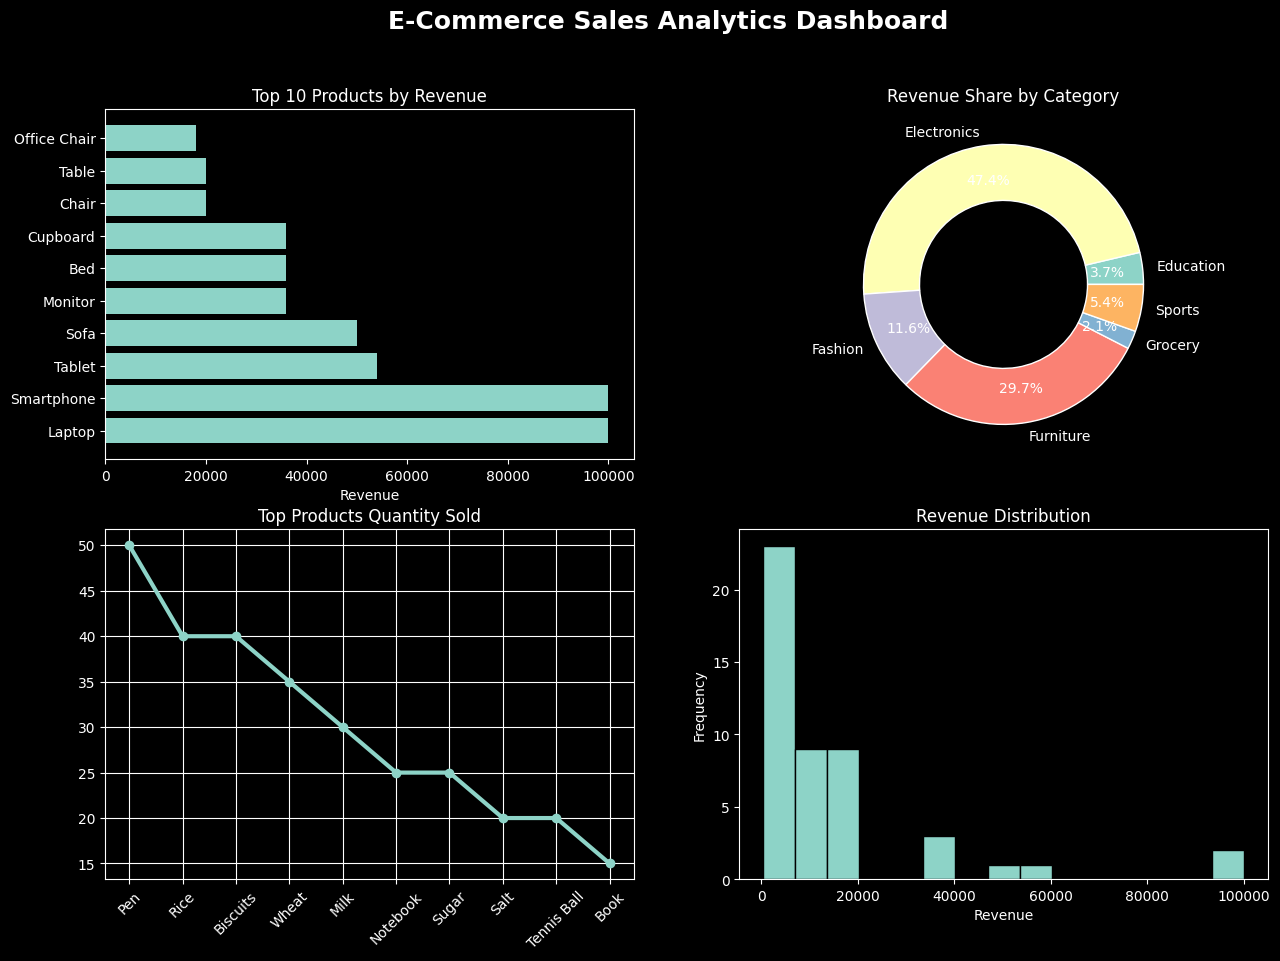

In [20]:
plt.style.use("dark_background")
fig, ax = plt.subplots(2, 2, figsize=(15,10))

plt.suptitle(
    "E-Commerce Sales Analytics Dashboard",
    fontsize=18,
    fontweight="bold"
)

top10 = df.nlargest(10, "revenue")

ax[0,0].barh(
    top10["product"],
    top10["revenue"]
)

ax[0,0].set_title("Top 10 Products by Revenue")
ax[0,0].set_xlabel("Revenue")

category_sales = df.groupby(
    "category"
)["revenue"].sum()

ax[0,1].pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    pctdistance=0.75,
    wedgeprops={
        "width":0.4,
        "edgecolor":"white"
    }
)

ax[0,1].set_title("Revenue Share by Category")


sorted_df = df.sort_values(
    "quantity",
    ascending=False
).head(10)

ax[1,0].plot(
    sorted_df["product"],
    sorted_df["quantity"],
    marker="o",
    linewidth=3
)

ax[1,0].set_title("Top Products Quantity Sold")
ax[1,0].tick_params(axis='x', rotation=45)
ax[1,0].grid(True)

ax[1,1].hist(
    df["revenue"],
    bins=15,
    edgecolor="black"
)

ax[1,1].set_title("Revenue Distribution")
ax[1,1].set_xlabel("Revenue")
ax[1,1].set_ylabel("Frequency")

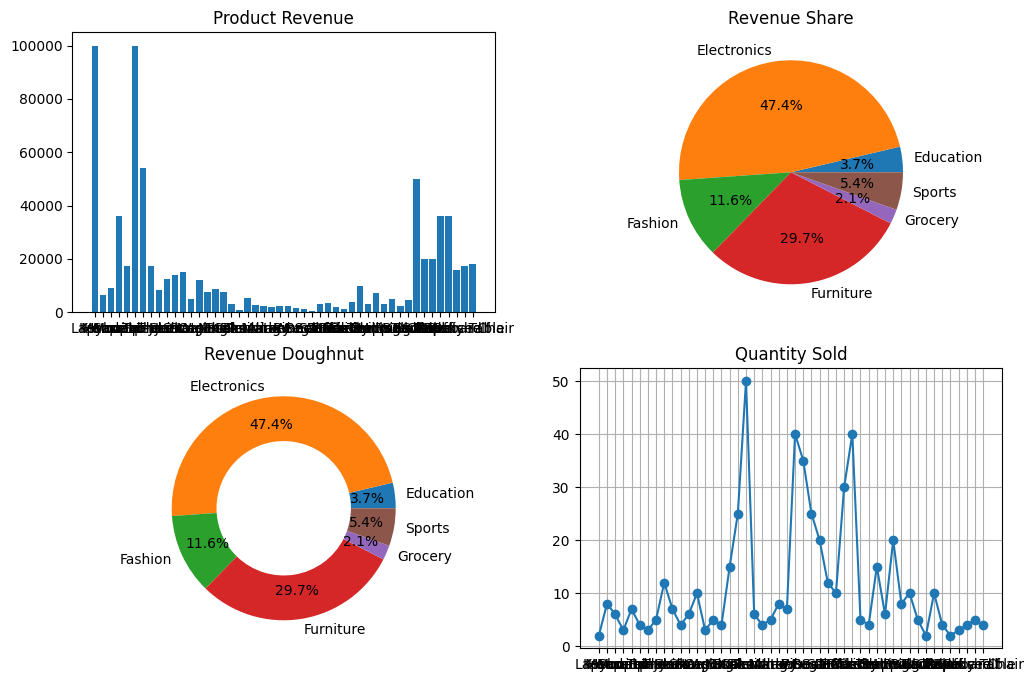

In [27]:
plt.style.use("default")
fig, ax = plt.subplots(
    2,
    2,
    figsize=(12,8)
)
ax[0,0].bar(
    df["product"],
    df["revenue"]
)

ax[0,0].set_title(
    "Product Revenue"
)

ax[0,1].pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%"
)

ax[0,1].set_title(
    "Revenue Share"
)

ax[1,0].pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    pctdistance=0.75,
    wedgeprops={
        "width":0.4
    }
)

ax[1,0].set_title(
    "Revenue Doughnut"
)

ax[1,1].plot(
    df["product"],
    df["quantity"],
    marker="o"
)

ax[1,1].set_title(
    "Quantity Sold"
)

ax[1,1].grid(True)



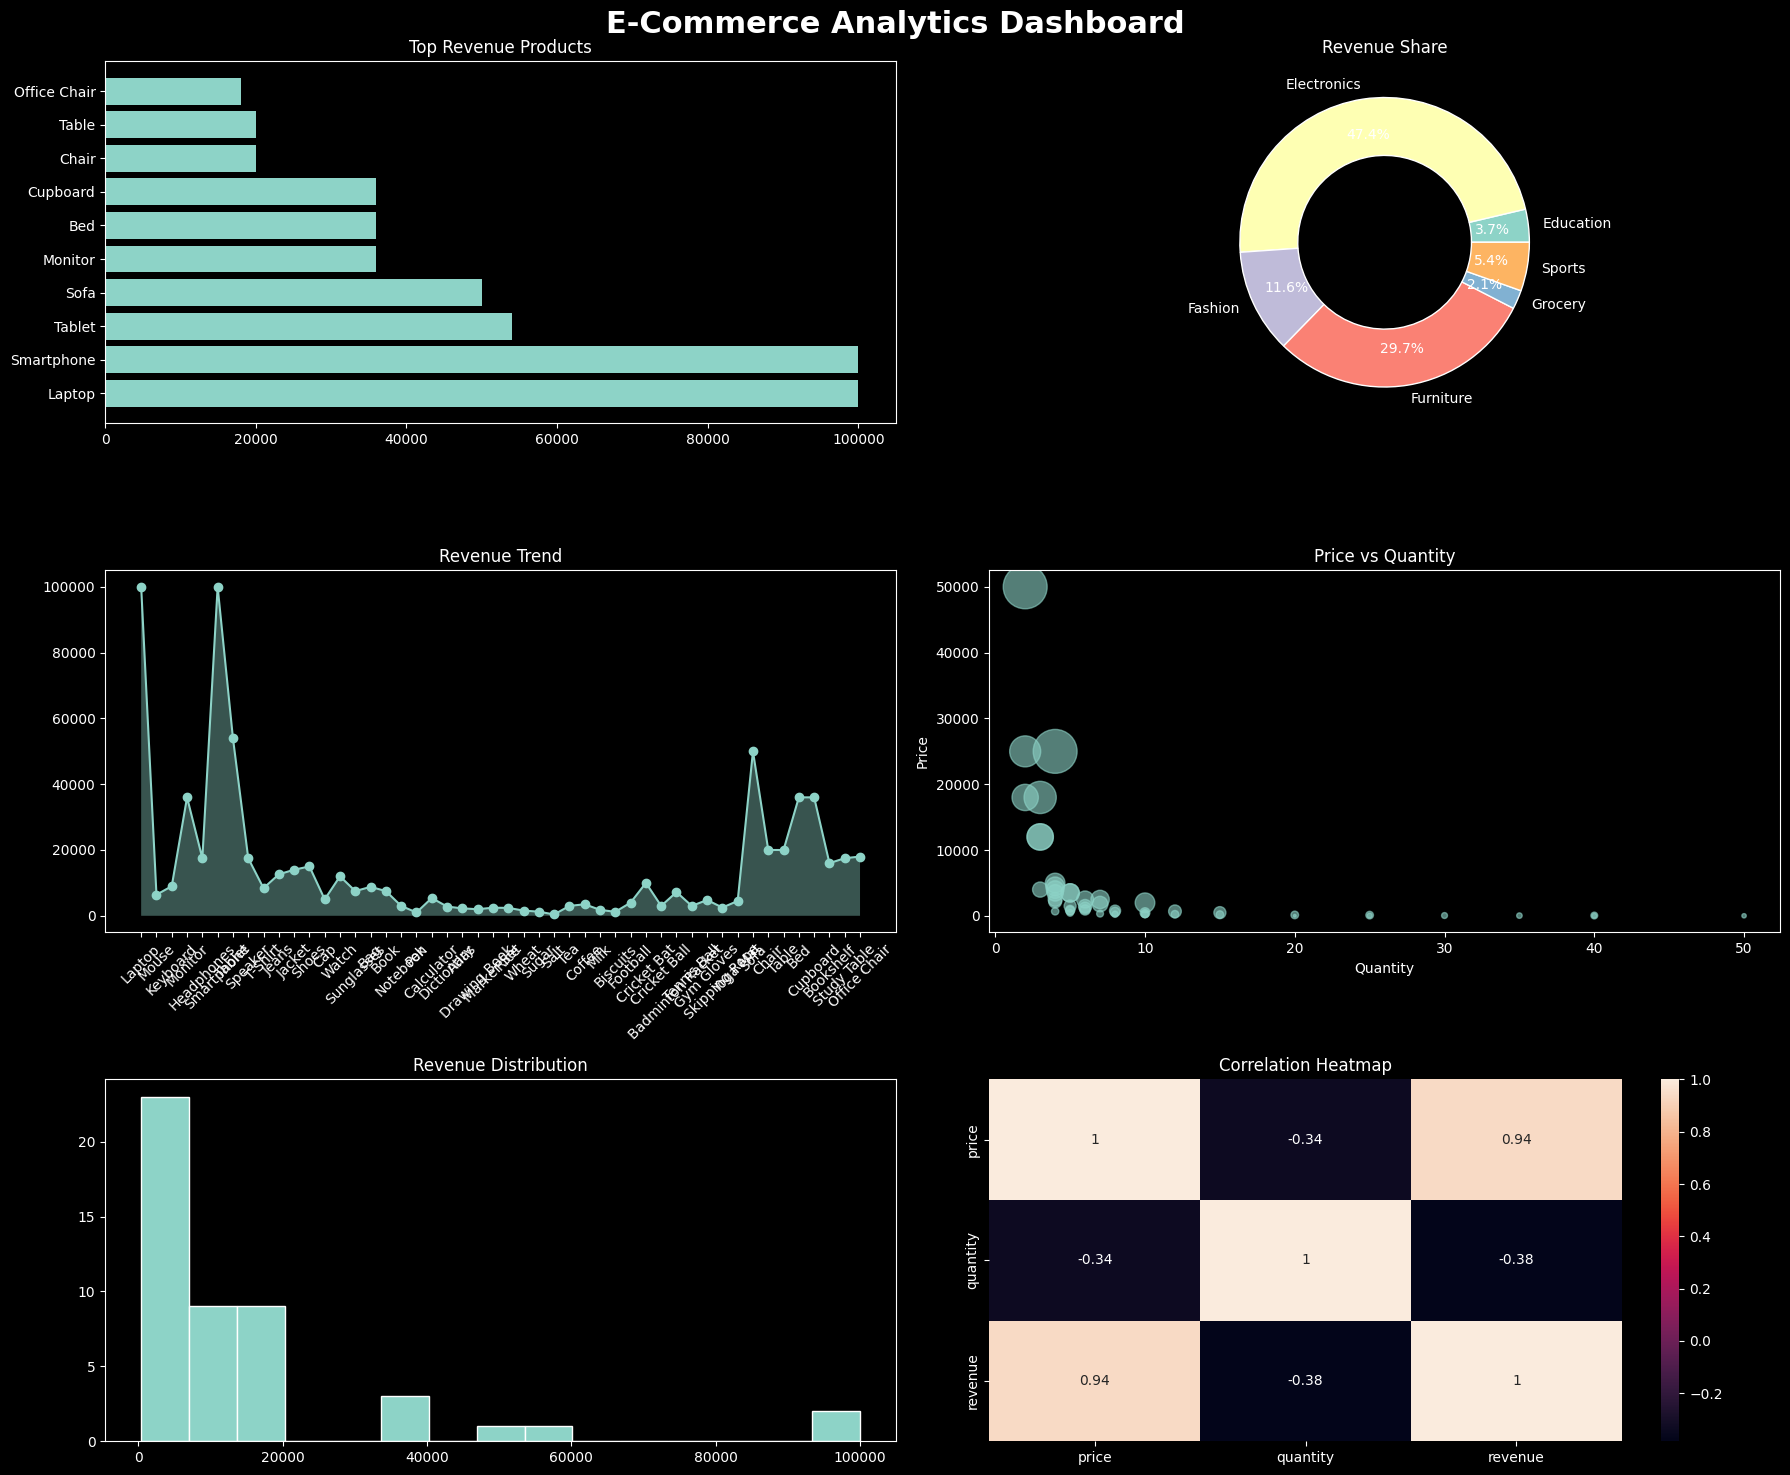

In [30]:
df["revenue"] = df["price"] * df["quantity"]

category_sales = df.groupby("category")["revenue"].sum()

top10 = df.nlargest(10, "revenue")

plt.style.use("dark_background")

fig, ax = plt.subplots(3, 2, figsize=(18, 15))

fig.suptitle(
    "E-Commerce Analytics Dashboard",
    fontsize=22,
    fontweight="bold"
)

# ===================================
# 1. Horizontal Revenue Ranking
# ===================================

ax[0,0].barh(
    top10["product"],
    top10["revenue"]
)

ax[0,0].set_title("Top Revenue Products")

# ===================================
# 2. Doughnut Chart
# ===================================

ax[0,1].pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    pctdistance=0.75,
    wedgeprops={
        "width":0.4,
        "edgecolor":"white"
    }
)

ax[0,1].set_title("Revenue Share")

# ===================================
# 3. Area Chart
# ===================================

ax[1,0].plot(
    df["product"],
    df["revenue"],
    marker="o"
)

ax[1,0].fill_between(
    df["product"],
    df["revenue"],
    alpha=0.4
)

ax[1,0].tick_params(
    axis="x",
    rotation=45
)

ax[1,0].set_title("Revenue Trend")

# ===================================
# 4. Bubble Chart
# ===================================

bubble = ax[1,1].scatter(
    df["quantity"],
    df["price"],
    s=df["revenue"]/100,
    alpha=0.6
)

ax[1,1].set_title("Price vs Quantity")

ax[1,1].set_xlabel("Quantity")

ax[1,1].set_ylabel("Price")

# ===================================
# 5. Histogram
# ===================================

ax[2,0].hist(
    df["revenue"],
    bins=15,
    edgecolor="white"
)

ax[2,0].set_title("Revenue Distribution")

# ===================================
# 6. Heatmap
# ===================================

corr = df[
    ["price",
     "quantity",
     "revenue"]
].corr()

sns.heatmap(
    corr,
    annot=True,
    ax=ax[2,1]
)

ax[2,1].set_title("Correlation Heatmap")

plt.tight_layout()

plt.show()

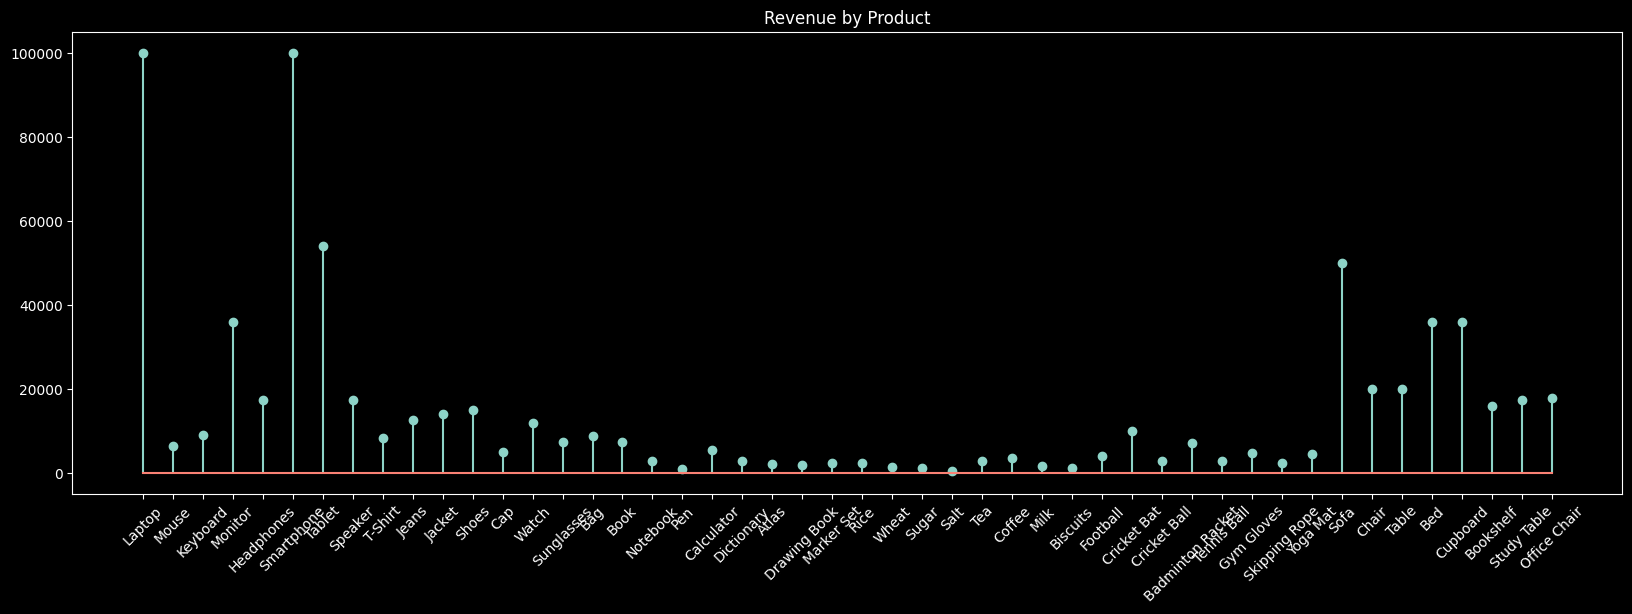

In [33]:
plt.figure(figsize=(20,6))

plt.stem(
    df["product"],
    df["revenue"]
)

plt.xticks(rotation=45)

plt.title("Revenue by Product")

plt.show()

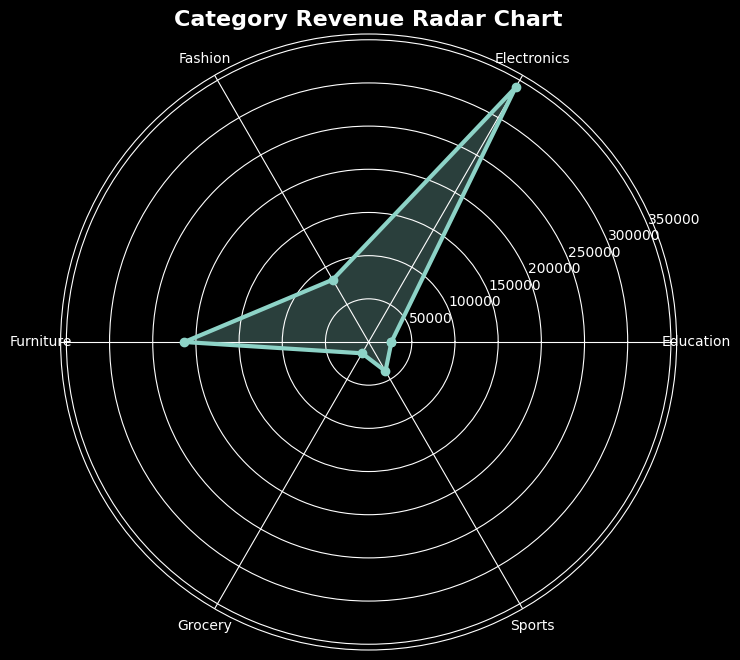

In [35]:
categories = category_sales.index.tolist()
values = category_sales.values.tolist()

# Close the circle
values += values[:1]

angles = np.linspace(
    0,
    2*np.pi,
    len(categories),
    endpoint=False
).tolist()

angles += angles[:1]

plt.figure(figsize=(8,8))

ax = plt.subplot(111, polar=True)

ax.plot(
    angles,
    values,
    linewidth=3,
    marker="o"
)

ax.fill(
    angles,
    values,
    alpha=0.3
)

ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    categories
)

plt.title(
    "Category Revenue Radar Chart",
    fontsize=16,
    fontweight="bold"
)

plt.show()